
# C6-pytorch — Session 2: `nn.Module` and Custom Layers

*One class session, roughly 85 minutes. Prerequisites: Session 1
(tensors, dtypes, the float64 convention, classes, inheritance,
`super()`, the `nn.Module` preview) and C5-neural-networks — in
particular C5's two NumPy helpers `affine_layer(x, W, b)` and
`step_activation(z)`, which this session rebuilds as torch modules.*

**This session:** the exam's PyTorch problems hand you a skeleton like
`class Something(nn.Module):` and ask you to finish it, wire hand-set
weights into it, and predict what it computes.
Today we earn that skill from parts you already own: C5's forward-pass
helpers become two custom torch **layers** — `DenseLayer` and
`ThresholdGate` — built on `nn.Module`, with their numbers registered
as `nn.Parameter`s, composed into a complete inference-only MLP whose
every weight we set by hand.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.set_default_dtype(torch.float64)   # course convention (Session 1 §2)



## 1. Where C5 Left Us: Two NumPy Helpers

C5 packaged its entire forward pass into two named helpers, and this
session keeps those names as the reference implementation.
Their contracts, restated:

- **`affine_layer(x, W, b)`** — the affine map of a dense layer.
  `W` has shape `(out, in)` (one *row* per output unit), `b` has shape
  `(out,)`, and each output unit $j$ computes
  $$z_j \;=\; \sum_k W_{jk}\, x_k \;+\; b_j ,$$
  which for a batch `x` of shape `(n, in)` is exactly `x @ W.T + b`.
- **`step_activation(z)`** — C5's threshold activation
  ($1$ where $z \ge 0$, else $0$), returned as floats.

*(A register note: several NumPy units banned `@` and `.T` inside
specific problems; those bans are per-problem contracts, not laws.
In torch-land `@` and `.T` are the house style, and this unit's
problems allow them unless a statement says otherwise.)*


In [2]:

def affine_layer(x, W, b):
    """C5's dense-layer map: rows of W are output units; returns x @ W.T + b."""
    return x @ W.T + b


def step_activation(z):
    """C5's threshold activation: 1.0 where z >= 0, else 0.0."""
    return (z >= 0).astype(float)


# a hand-set 2 -> 2 -> 1 network from the C5 register:
# hidden unit 1 fires iff x1 + x2 - 1 >= 0, hidden unit 2 iff x1 - x2 + 1 >= 0,
# and the readout fires iff BOTH hidden units fire (h1 + h2 - 1.5 >= 0).
W1 = np.array([[1.0, 1.0],
               [1.0, -1.0]])
b1 = np.array([-1.0, 1.0])
W2 = np.array([[1.0, 1.0]])
b2 = np.array([-1.5])

pts = np.array([[1.0, 0.5], [0.2, 0.3], [-0.5, 0.2], [2.0, -3.0]])
h_np = step_activation(affine_layer(pts, W1, b1))
out_np = step_activation(affine_layer(h_np, W2, b2))
print("hidden activations:")
print(h_np)
print("network output:", out_np.ravel())


hidden activations:
[[1. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]
network output: [1. 0. 0. 0.]



Only the first point fires both hidden units (`[1., 1.]` in the first
row) and so only it survives the AND readout: the output row reads
`[1., 0., 0., 0.]`.
Keep this NumPy pipeline in view — the rest of the session rebuilds it
piece for piece in torch, and the two versions must agree to the digit.

### Checkpoint 1

1. By hand: `affine_layer(x, W, b)` for `x = [2.0, 1.0]`,
   `W = [[1.0, -1.0], [0.5, 2.0]]`, `b = [0.0, -1.0]` — both outputs.
2. What does `step_activation` return for `z = [0.0, -0.3, 2.0]`, and
   which convention decides the value at exactly $0$?
3. For a batch `x` of shape `(50, 3)` and a layer with `W` of shape
   `(4, 3)`: what shape does `affine_layer(x, W, b)` return, and what
   shape must `b` have?



## 2. First Custom Module: `ThresholdGate`

**Motivation.**
Session 1 §7 showed the anatomy: subclass `nn.Module`, call
`super().__init__()`, define `forward`.
The easiest layer to port is the activation, because it holds no
numbers of its own — a **parameter-free module**.
For such a class we need no `__init__` at all: Session 1 §6's inheritance
rule says the base class's `__init__` runs automatically when we define
none.


In [3]:

class ThresholdGate(nn.Module):
    """C5's step_activation as a torch layer: 1 where x >= 0, else 0."""

    def forward(self, x):
        return (x >= 0).to(x.dtype)


gate = ThresholdGate()
z = torch.tensor([-1.0, 0.0, 2.0])
print("gate(z):           ", gate(z))
print("matches C5 helper: ", np.allclose(gate(z).numpy(), step_activation(np.array([-1.0, 0.0, 2.0])), atol=0, rtol=0))
print("parameters:        ", list(gate.parameters()))


gate(z):            tensor([0., 1., 1.])
matches C5 helper:  True
parameters:         []



Three things to read off the printout:

- `gate(z)` gives `tensor([0., 1., 1.])` — the module is *called like a
  function* and the inherited `__call__` machinery runs our `forward`
  (Session 1 §7);
- it agrees with `step_activation` exactly (`True`) — same `>=`
  convention, same values, compared across the border with an explicit
  `.numpy()`;
- `list(gate.parameters())` prints `[]`: the module carries no numbers,
  and next session's counting problems will care that gates contribute
  **zero** parameters.

The one torch idiom worth staring at is `.to(x.dtype)`: comparisons
produce a *boolean* tensor, and casting to the input's own dtype keeps
the output ready for further float arithmetic — the torch spelling of
C5's `astype(float)`, but adaptive to whatever float dtype flows in.

### Checkpoint 2

1. `ThresholdGate` defines no `__init__` — why is that legal, and
   which `__init__` runs when you build one?
2. Predict `ThresholdGate()(torch.tensor([[0.5], [-0.5]]))` — values,
   shape, and dtype.
3. Why does `forward` end in `.to(x.dtype)` rather than returning the
   raw comparison result?



## 3. Registering Numbers: `nn.Parameter` and `DenseLayer`

**Motivation.**
`affine_layer` is different: it *owns numbers* — `W` and `b`.
A torch module must store its numbers so that torch can *see* them:
enumerate them, report their shapes, save and load them.
The container for that is **`nn.Parameter`** — a tensor that, when
assigned as a module attribute, is **registered**: it appears in
`parameters()`, in `named_parameters()`, and in the module's
`state_dict` (Session 3 tours all three).

One honest sentence about the flag you are about to see: full PyTorch
can compute gradients of a module's output with respect to its
registered parameters and use them to train the network — machinery
that this course and the exam's torch problems never touch, which is
why every parameter we register is constructed with
**`requires_grad=False`**: our weights are hand-set constants, not
quantities anything will adjust.

Here is C5's dense layer as a module, the unit's pinned spec:


In [4]:

class DenseLayer(nn.Module):
    """C5's affine_layer as a torch layer.

    weight has shape (out, in) -- one row per output unit, as in C5.
    bias has shape (out,).  forward(x) = x @ weight.T + bias.
    """

    def __init__(self, weight, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.as_tensor(weight), requires_grad=False)
        self.bias = nn.Parameter(torch.as_tensor(bias), requires_grad=False)

    def forward(self, x):
        return x @ self.weight.T + self.bias


hidden = DenseLayer(torch.tensor(W1), torch.tensor(b1))
x_t = torch.from_numpy(pts).to(torch.float64)          # explicit cast at the border
print("torch layer:", hidden(x_t)[0], "...")
print("NumPy helper:", affine_layer(pts, W1, b1)[0], "...")
print("agree within 1e-12:", np.allclose(
    hidden(x_t).numpy(), affine_layer(pts, W1, b1), atol=1e-12, rtol=0
))
for name, p in hidden.named_parameters():
    print(f"registered: {name}  shape {tuple(p.shape)}  requires_grad={p.requires_grad}")


torch layer: tensor([0.5000, 1.5000]) ...
NumPy helper: [0.5 1.5] ...
agree within 1e-12: True
registered: weight  shape (2, 2)  requires_grad=False
registered: bias  shape (2,)  requires_grad=False



The torch layer reproduces `affine_layer` on the same points
(`agree exactly: True`), and the loop at the end shows what
registration bought us: the module can *report its own contents* —
`weight  shape (2, 2)` and `bias  shape (2,)`, both with
`requires_grad=False`.

**Why `nn.Parameter` and not a plain tensor?**
Assign plain tensors and the numbers still compute — but they become
invisible to every inspection tool:


In [5]:

class GhostDense(nn.Module):
    """BROKEN register: plain tensors instead of nn.Parameter."""

    def __init__(self, weight, bias):
        super().__init__()
        self.weight = torch.as_tensor(weight)     # not registered!
        self.bias = torch.as_tensor(bias)         # not registered!

    def forward(self, x):
        return x @ self.weight.T + self.bias


ghost = GhostDense(torch.tensor(W1), torch.tensor(b1))
print("same outputs:      ", bool((ghost(x_t) == hidden(x_t)).all()))
print("ghost parameters():", list(ghost.parameters()))
print("ghost state_dict():", dict(ghost.state_dict()))


same outputs:       True
ghost parameters(): []
ghost state_dict(): {}



`same outputs: True`, yet `parameters()` and `state_dict()` are both
**empty** — the layer's numbers would be skipped by parameter counts,
missing from saved weights, and invisible to every tool Session 3
builds on.
No error is raised anywhere; this is the quietest bug in the unit, and
the rule that prevents it is one line long: **module numbers are
registered as `nn.Parameter(..., requires_grad=False)`, always.**

### Checkpoint 3

1. For `DenseLayer` with `out = 4`, `in = 2`: state the shapes of the
   two registered parameters.
2. A module stores its matrix as a plain tensor attribute.
   Which behaviors stay correct, and which break?
3. What does `list(GhostDense(W, b).parameters())` print, and what
   single change fixes it?



## 4. The `requires_grad` Flag, Up Close

**Motivation.**
The flag deserves one careful look, because torch's *default* disagrees
with our discipline and the exam reads the difference.


In [6]:

p_default = nn.Parameter(torch.zeros(3))
p_course = nn.Parameter(torch.zeros(3), requires_grad=False)
plain = torch.zeros(3)
print("nn.Parameter default flag:", p_default.requires_grad)
print("course construction:      ", p_course.requires_grad)
print("plain tensor default:     ", plain.requires_grad)

print("all DenseLayer params frozen:",
      all(not p.requires_grad for p in hidden.parameters()))


nn.Parameter default flag: True
course construction:       False
plain tensor default:      False
all DenseLayer params frozen: True



Read the three lines as a table:

| object | `requires_grad` |
|---|---|
| `nn.Parameter(t)` | `True` — torch assumes a registered number is adjustable |
| `nn.Parameter(t, requires_grad=False)` | `False` — this course's construction |
| plain tensor | `False` |

Two facts to keep straight:

- **The flag never changes what `forward` computes.**
  It is bookkeeping about *intent* — with the flag `True` or `False`,
  `x @ weight.T + bias` produces identical numbers, and a forward pass
  never modifies any stored parameter either way (p16 makes you verify
  both claims).
- **Our discipline is `requires_grad=False` on every parameter**, for
  the reason §3's scope sentence gave: everything in this unit is
  hand-set and fixed, and the flag documents exactly that.
  A quick audit idiom:
  `all(not p.requires_grad for p in module.parameters())`.

### Checkpoint 4

1. What is `nn.Parameter(torch.ones(2)).requires_grad`, and what does
   the course construction write instead?
2. Two copies of `DenseLayer` differ only in their parameters'
   `requires_grad` flags. Do their `forward` outputs differ?
3. Write the one-line audit that a module `m` obeys the course's
   all-frozen discipline.



## 5. Composing an Inference-Only MLP with Manual Weights

**Motivation.**
Layers become a network by *composition*, and `nn.Module` has one more
registration trick for it: assign a **module** as an attribute (after
`super().__init__()`), and the parent registers it as a **submodule** —
its parameters join the parent's `parameters()` under dotted names.

We now rebuild §1's NumPy network as a torch module, same hand-set
weights, same architecture $2 \to 2 \to 1$:


In [7]:

class TinyMLP(nn.Module):
    """Section 1's 2 -> 2 -> 1 hand-weighted network, as one module."""

    def __init__(self, W1, b1, W2, b2):
        super().__init__()
        self.hidden = DenseLayer(W1, b1)     # submodule registration
        self.gate = ThresholdGate()
        self.readout = DenseLayer(W2, b2)

    def forward(self, x):
        h = self.gate(self.hidden(x))
        return self.gate(self.readout(h))


mlp = TinyMLP(torch.tensor(W1), torch.tensor(b1), torch.tensor(W2), torch.tensor(b2))
print("torch output:", mlp(x_t).ravel())
print("NumPy output:", out_np.ravel())
for name, p in mlp.named_parameters():
    print(f"{name:16s} shape {tuple(p.shape)}  requires_grad={p.requires_grad}")


torch output: tensor([1., 0., 0., 0.])
NumPy output: [1. 0. 0. 0.]
hidden.weight    shape (2, 2)  requires_grad=False
hidden.bias      shape (2,)  requires_grad=False
readout.weight   shape (1, 2)  requires_grad=False
readout.bias     shape (1,)  requires_grad=False



The torch network reproduces the NumPy pipeline —
`tensor([1., 0., 0., 0.])` against `[1. 0. 0. 0.]` — and
`named_parameters()` now shows **dotted names** built from the
attribute path: `hidden.weight`, `hidden.bias`, `readout.weight`,
`readout.bias`.
The gate appears in no name because it owns nothing.
Note also that one `ThresholdGate` instance served both stops in
`forward` — parameter-free modules can be reused freely.

Geometrically this network is pure C5: each hidden unit fires on a
half-plane, and the readout ANDs them.
Painting its decision over random points shows the wedge where both
half-planes overlap:


network fires on 78 of 300 points
matches the direct half-plane check on all points: True


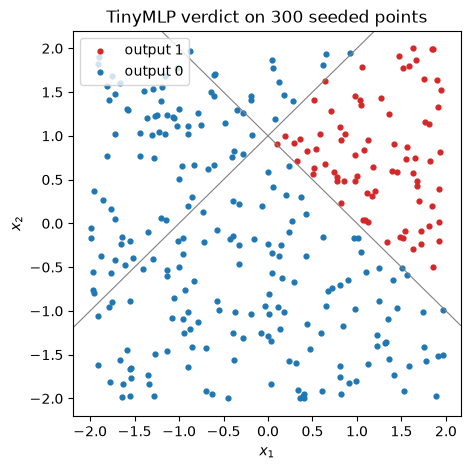

In [8]:

torch.manual_seed(20260804)
cloud = torch.rand(300, 2) * 4 - 2            # 300 points in [-2, 2)^2
verdict = mlp(cloud).ravel()

direct = ((cloud[:, 0] + cloud[:, 1] >= 1) & (cloud[:, 0] - cloud[:, 1] >= -1)).to(cloud.dtype)
print("network fires on", int(verdict.sum()), "of 300 points")
print("matches the direct half-plane check on all points:", bool((verdict == direct).all()))

plt.figure(figsize=(5, 5))
for value, color, tag in ((1.0, "C3", "output 1"), (0.0, "C0", "output 0")):
    sel = verdict == value
    plt.scatter(cloud[sel, 0].numpy(), cloud[sel, 1].numpy(), s=12, color=color, label=tag)
plt.axline((0, 1), (1, 0), color="gray", linewidth=0.8)     # x1 + x2 = 1
plt.axline((-1, 0), (0, 1), color="gray", linewidth=0.8)    # x1 - x2 = -1
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("TinyMLP verdict on 300 seeded points")
plt.legend()
plt.show()



The seeded cloud has 78 points the network fires on, every one agreeing
with the direct boolean check (`True`) — the red wedge between the two
gray boundary lines.
Everything here was *engineered*: weights chosen by hand to implement a
specification, then run forward.
That is the whole torch workflow of this course and of the exam's
PyTorch problems — inference engineering, not fitting.

### Checkpoint 5

1. List the four dotted parameter names of `TinyMLP` and each shape.
2. Hand-run the network on $(1.0,\ 0.5)$: hidden pre-activations,
   gated values, readout, final output.
3. Which line of `TinyMLP` registers `hidden` as a submodule, and what
   would `named_parameters()` show if `self.hidden` were created
   *before* `super().__init__()`?



## 6. `nn.Sequential`: Composition as a One-Liner

**Motivation.**
When a network is a straight chain — layer, gate, layer, gate — torch
offers a ready-made container: **`nn.Sequential`** runs its children in
order, and *is itself* an `nn.Module`, so calling, parameter listing,
and registration all work unchanged.


In [9]:

chain = nn.Sequential(
    DenseLayer(torch.tensor(W1), torch.tensor(b1)),
    ThresholdGate(),
    DenseLayer(torch.tensor(W2), torch.tensor(b2)),
    ThresholdGate(),
)

print("same outputs as TinyMLP:", bool((chain(x_t) == mlp(x_t)).all()))
print("chain[0] is the first DenseLayer:", type(chain[0]).__name__)
for name, p in chain.named_parameters():
    print(f"{name:12s} shape {tuple(p.shape)}")


same outputs as TinyMLP: True
chain[0] is the first DenseLayer: DenseLayer
0.weight     shape (2, 2)
0.bias       shape (2,)
2.weight     shape (1, 2)
2.bias       shape (1,)



Same outputs (`True`), and the children are indexable — `chain[0]` is
the first `DenseLayer`.
Sequential names its children by *position*, so the parameters appear
as `0.weight`, `0.bias`, `2.weight`, `2.bias` (the gates at positions
1 and 3 own nothing).

When to write which:

- **`nn.Sequential`** when the computation is a pure pipe;
- **a custom class** when you want named attributes, non-chain wiring
  (an input reused in two places, parts combined), or any logic in
  `forward` beyond "next, please."

The exam writes both; you must read both.

### Checkpoint 6

1. Rebuild `TinyMLP` as an `nn.Sequential` (order of the four
   children?).
2. In that Sequential, what are the dotted names of the second dense
   layer's parameters?
3. Give one architecture from this course that `nn.Sequential` cannot
   express, and say why.



## 7. Worked Exam-Style Example: a Module to Specification

Constrained module-building is a staple of the exam's torch cluster.
Here is one solved in full, in the real register.

---

**Problem (constrained coding; reasoning is not required).**
Implement a module `Amplifier(nn.Module)`:

- the constructor takes `gain`, a 1-D tensor of shape `(d,)`, and
  registers it as a parameter named `gain`, constructed with
  `requires_grad=False`;
- `forward(x)` takes `x` of shape `(n, d)` and returns `x * gain`
  (each column scaled by its own gain entry).

**Banned (zero points): `nn.Linear` or any built-in parametric torch
layer; loops.**
Verify on `x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])` with
`gain = torch.tensor([2.0, -1.0, 0.5])`.

---

**Solution, step by step.**

*Step 1 — read the contract.*
One registered parameter (`gain`, shape `(d,)`), one broadcast multiply.
The bans close the workaround of wrapping a built-in layer: the skill
being graded is the registration itself.

*Step 2 — skeleton.*
Subclass, `super().__init__()` first, then the registration, then
`forward`.

*Step 3 — the forward.*
`x * self.gain` broadcasts `(n, d) * (d,)` by F1's trailing-dimensions
rule — no loop wanted or needed.


In [10]:

class Amplifier(nn.Module):
    def __init__(self, gain):
        super().__init__()
        self.gain = nn.Parameter(torch.as_tensor(gain), requires_grad=False)

    def forward(self, x):
        return x * self.gain


amp = Amplifier(torch.tensor([2.0, -1.0, 0.5]))
x_demo = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print(amp(x_demo))
print("registered:", [(n, tuple(p.shape), p.requires_grad) for n, p in amp.named_parameters()])


tensor([[ 2.0000, -2.0000,  1.5000],
        [ 8.0000, -5.0000,  3.0000]])
registered: [('gain', (3,), False)]



*Step 4 — self-check against the contract.*
The output `[[2., -2., 1.5], [8., -5., 3.]]` shows column $k$ scaled by
`gain[k]`; the registration line reports exactly one parameter,
`('gain', (3,), False)` — name, shape, and flag all as specified.
Contract met, bans respected.

### Checkpoint 7

1. Extend the spec: `Amplifier2` also takes `offset` (shape `(d,)`),
   registered the same way, and computes `x * gain + offset`.
   Which lines change, and how many parameters does
   `named_parameters()` now report?
2. Why would `self.gain = torch.as_tensor(gain)` (no `nn.Parameter`)
   earn zero under this rubric even though the printed output of
   `amp(x_demo)` is identical?



## 8. Common Pitfalls II

**Pitfall 1 — the transposed forward.**
The pinned convention stores `weight` as `(out, in)` and computes
`x @ weight.T + bias`.
Write `x @ weight + bias` instead and *square* layers silently compute
the wrong thing — no shape error to save you:


In [11]:

Wsq = torch.tensor([[1.0, 2.0], [3.0, 4.0]])     # (2, 2): square, the dangerous case
bsq = torch.tensor([0.0, 0.0])
xq = torch.tensor([[1.0, 0.0]])

right = xq @ Wsq.T + bsq                          # unit outputs: rows of W
wrong = xq @ Wsq + bsq                            # BROKEN: columns of W
print("correct  :", right)
print("broken   :", wrong)

W_rect = torch.zeros(3, 2)                        # (out=3, in=2): non-square saves you
try:
    xq @ W_rect + torch.zeros(3)
except RuntimeError as e:
    print("non-square at least errors ->", str(e)[:60], "...")


correct  : tensor([[1., 3.]])
broken   : tensor([[1., 2.]])
non-square at least errors -> mat1 and mat2 shapes cannot be multiplied (1x2 and 3x2) ...



On the square layer the broken form runs happily and returns
`[[1., 2.]]` where the spec demands `[[1., 3.]]` — for input
$(1, 0)$, output $j$ must be row $j$'s first entry ($W_{j0} + b_j$:
$1$ and $3$), and only the `.T` form delivers that.
Non-square layers at least crash with a shape mismatch.
Defense: test any hand-written layer on a *one-hot input*, where the
correct answer is a column of `weight` plus `bias` — readable by eye.

**Pitfall 2 — mixed dtypes at the border.**
Matrix products refuse mixed precision:


In [12]:

x32 = torch.rand(2, 2, dtype=torch.float32)       # arrived from float32 code
W64 = torch.eye(2)                                 # float64 under the course default
try:
    x32 @ W64
except RuntimeError as e:
    print("RuntimeError:", e)

print("fixed:", (x32.to(torch.float64) @ W64).dtype)


RuntimeError: expected m1 and m2 to have the same dtype, but got: float != double
fixed: torch.float64



The message names both dtypes (`expected m1 and m2 to have the same
dtype, but got: float != double`); the fix is Session 1 §4's rule —
cast explicitly at
every border, `x32.to(torch.float64)`, after which the product is
float64.

**Pitfall 3 — a module without a `forward`.**
Misspell or forget `forward` and construction succeeds; only the *call*
fails:


In [13]:

class Nameless(nn.Module):
    def foward(self, x):                          # BROKEN: typo, torch never sees it
        return x


try:
    Nameless()(torch.tensor([1.0]))
except NotImplementedError as e:
    print("NotImplementedError:", str(e).strip())


NotImplementedError: Module [Nameless] is missing the required "forward" function



`Module [Nameless] is missing the required "forward" function` — torch
dispatches calls to a method named exactly `forward`; any other name is
just an unused method.
The construction-time silence is what makes the typo sneaky: the bug
waits for the first call.

### Checkpoint 8

1. A hand-built $3 \to 3$ layer passes shape checks but gives wrong
   values. Which pitfall do you suspect first, and what one-hot test
   settles it?
2. `t32 @ t64` raises
   `RuntimeError: expected ... same dtype`. Two different one-line
   fixes?
3. `m = M(); m(x)` raises
   `NotImplementedError: Module [M] is missing the required "forward"
   function`, yet `M` seems to define one. What is the likely cause?



## Checkpoint Answers

<details><summary><b>Checkpoint 1</b></summary>

1. Unit 1: $1 \cdot 2 + (-1) \cdot 1 + 0 = 1$; unit 2:
   $0.5 \cdot 2 + 2 \cdot 1 - 1 = 2$. Output `[1.0, 2.0]`.
2. `[1.0, 0.0, 1.0]` — the C5 convention is $z \ge 0 \mapsto 1$, so
   exactly $0$ fires.
3. Output `(50, 4)` (`x @ W.T` is `(50, 3) @ (3, 4)`); `b` must have
   shape `(4,)`, broadcast across the 50 rows.

</details>

<details><summary><b>Checkpoint 2</b></summary>

1. Defining no `__init__` means the base class's is inherited and runs
   automatically — `nn.Module.__init__` — so the module is properly
   set up with nothing extra stored.
2. `tensor([[1.], [0.]])`, shape `(2, 1)`, dtype `torch.float64`
   (the output dtype follows the input's).
3. The comparison yields a *boolean* tensor; `.to(x.dtype)` converts to
   the input's float dtype so downstream arithmetic (the next dense
   layer's matmul) receives floats, mirroring C5's `astype(float)`.

</details>

<details><summary><b>Checkpoint 3</b></summary>

1. `weight`: `(4, 2)`; `bias`: `(4,)`.
2. Stays correct: `forward` outputs (the arithmetic never cared).
   Breaks: `parameters()`, `named_parameters()`, `state_dict()` — the
   numbers are invisible to counting, saving, and inspection.
3. `[]` — an empty list. Fix: wrap each tensor as
   `nn.Parameter(..., requires_grad=False)` when assigning.

</details>

<details><summary><b>Checkpoint 4</b></summary>

1. `True` — torch's default assumption; the course writes
   `nn.Parameter(t, requires_grad=False)`.
2. No — identical outputs on identical inputs. The flag is intent
   bookkeeping, not arithmetic.
3. `all(not p.requires_grad for p in m.parameters())`.

</details>

<details><summary><b>Checkpoint 5</b></summary>

1. `hidden.weight` `(2, 2)`; `hidden.bias` `(2,)`;
   `readout.weight` `(1, 2)`; `readout.bias` `(1,)`.
2. Pre-activations: $1 + 0.5 - 1 = 0.5$ and $1 - 0.5 + 1 = 1.5$;
   gated: $(1, 1)$; readout: $1 + 1 - 1.5 = 0.5$; output $1$.
3. The assignment `self.hidden = DenseLayer(W1, b1)` — attribute
   assignment of a module is the registration.
   Before `super().__init__()` it would instead raise
   `AttributeError: cannot assign module before Module.__init__()
   call` — the Session 1 §7 guard, so there is nothing to show.

</details>

<details><summary><b>Checkpoint 6</b></summary>

1. `nn.Sequential(DenseLayer(W1, b1), ThresholdGate(),
   DenseLayer(W2, b2), ThresholdGate())`.
2. `2.weight` and `2.bias` — position 2 in the chain.
3. Any non-chain wiring — e.g. a module that adds its raw input to a
   transformed copy of itself (a skip connection, `C7-cnn-transfer`'s
   territory), or any `forward` that uses a value twice; Sequential can
   only feed each child the previous child's output.

</details>

<details><summary><b>Checkpoint 7</b></summary>

1. The constructor gains
   `self.offset = nn.Parameter(torch.as_tensor(offset),
   requires_grad=False)` and `forward` returns
   `x * self.gain + self.offset`; `named_parameters()` reports two
   entries.
2. The rubric grades the registration contract, not just output
   values: an unregistered `gain` is invisible to
   `parameters()`/`state_dict()`, so the module fails the stated spec
   ("registers it as a parameter") — the §3 ghost bug, and the ban
   register's zero-points clause applies.

</details>

<details><summary><b>Checkpoint 8</b></summary>

1. Pitfall 1, the transposed forward — squares hide it.
   Feed the one-hot $(1, 0, 0)$: the output must equal
   `weight[:, 0] + bias` (first *column* plus bias); the transposed
   version returns the first *row* plus bias instead.
2. `t32.to(torch.float64) @ t64`, or `t32 @ t64.to(torch.float32)` —
   pick the precision on purpose (course default: float64; if staying
   float32, compare with `atol=1e-6`/`rtol=1e-5`).
3. The method is misspelled (e.g. `foward`) or indented outside the
   class — torch only dispatches to a method named exactly `forward`.

</details>
